# Part 4 — Vector Databases: Embedding & Similarity (Colab-ready)

**Instructions**: Run this notebook in **Google Colab**. When done, go to **Runtime → Run all**, wait for all outputs, then **File → Save a copy in Drive** and **File → Download .ipynb**. Commit the downloaded file back to your repo so outputs are visible.


In [ ]:
# Install dependencies (Colab)
!pip -q install sentence-transformers seaborn matplotlib numpy pandas scikit-learn

## 4.1 — Create 10 sentences across exactly 3 topics
Topics: **Cricket**, **Cooking**, **Cybersecurity** (at least 3 per topic; total 10).

In [ ]:
import pandas as pd
from pprint import pprint

sentences = [
    # Cricket (4)
    'The opening batsman drove the ball through covers for a boundary.',
    'The bowler set a tight field and forced a defensive shot.',
    'Spin from the rough made the ball sharply turn past the bat.',
    'A quick single brought up the century partnership.',
    # Cooking (3)
    'Simmer the tomatoes with garlic and basil to build a rich sauce.',
    'Whisk the eggs and fold in the butter for a silky omelette.',
    'Roast the vegetables at high heat to caramelize their edges.',
    # Cybersecurity (3)
    'The analyst detected lateral movement using abnormal login patterns.',
    'Enable multi-factor authentication to reduce credential theft.',
    'Encrypt data at rest and in transit to mitigate breach impact.'
]

assert len(sentences) == 10
pprint(sentences)


['The opening batsman drove the ball through covers for a boundary.',
 'The bowler set a tight field and forced a defensive shot.',
 'Spin from the rough made the ball sharply turn past the bat.',
 'A quick single brought up the century partnership.',
 'Simmer the tomatoes with garlic and basil to build a rich sauce.',
 'Whisk the eggs and fold in the butter for a silky omelette.',
 'Roast the vegetables at high heat to caramelize their edges.',
 'The analyst detected lateral movement using abnormal login patterns.',
 'Enable multi-factor authentication to reduce credential theft.',
 'Encrypt data at rest and in transit to mitigate breach impact.']


## Generate embeddings using sentence-transformers (all-MiniLM-L6-v2)

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences, normalize_embeddings=True)  # shape (10, 384)
embeddings.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(10, 384)

## Compute 10×10 cosine similarity matrix and show as heatmap

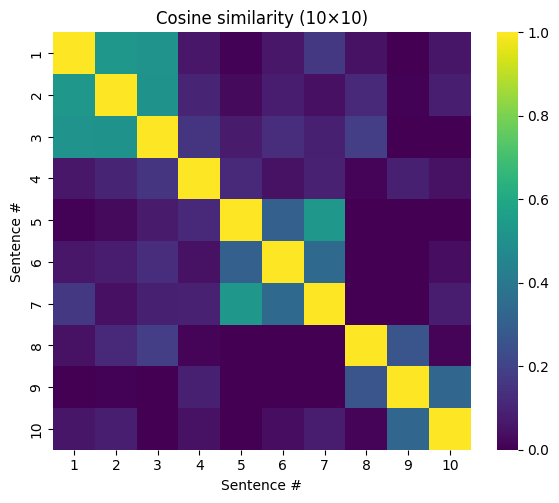

,1,2,3,4,5,6,7,8,9,10
1,1.000,0.532,0.515,0.061,0.005,0.062,0.160,0.044,-0.074,0.056
2,0.532,1.000,0.505,0.098,0.025,0.076,0.040,0.114,0.006,0.085
3,0.515,0.505,1.000,0.152,0.071,0.125,0.087,0.183,-0.010,-0.043
4,0.061,0.098,0.152,1.000,0.117,0.043,0.091,0.010,0.088,0.045
5,0.005,0.025,0.071,0.117,1.000,0.303,0.529,-0.098,-0.035,-0.036
6,0.062,0.076,0.125,0.043,0.303,1.000,0.338,-0.065,-0.012,0.033
7,0.160,0.040,0.087,0.091,0.529,0.338,1.000,-0.057,-0.019,0.075
8,0.044,0.114,0.183,0.010,-0.098,-0.065,-0.057,1.000,0.264,0.011
9,-0.074,0.006,-0.010,0.088,-0.035,-0.012,-0.019,0.264,1.000,0.332
10,0.056,0.085,-0.043,0.045,-0.036,0.033,0.075,0.011,0.332,1.000


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns, matplotlib.pyplot as plt

sim = cosine_similarity(embeddings)
df_sim = pd.DataFrame(sim, index=range(1,11), columns=range(1,11))
plt.figure(figsize=(6,5))
sns.heatmap(df_sim, vmin=0, vmax=1, cmap='viridis', square=True, annot=False)
plt.title('Cosine similarity (10×10)')
plt.xlabel('Sentence #')
plt.ylabel('Sentence #')
plt.tight_layout()
plt.show()
df_sim.round(3)  # display numeric matrix too


## Query: find top 2 most similar sentences
New query: *"The bowler took three wickets in one over"*

In [ ]:
query_sentence = 'The bowler took three wickets in one over'
q_emb = model.encode([query_sentence], normalize_embeddings=True)
scores = cosine_similarity(q_emb, embeddings).ravel()
top_idx = np.argsort(scores)[-2:][::-1]  # top 2 indices
print('Query:', query_sentence)
for rank, i in enumerate(top_idx, start=1):
    print(f'Top {rank}: idx={i}, score={scores[i]:.4f}, sentence="{sentences[i]}"')


Query: The bowler took three wickets in one over
Top 1: idx=1, score=0.5626, sentence="The bowler set a tight field and forced a defensive shot."
Top 2: idx=0, score=0.4929, sentence="The opening batsman drove the ball through covers for a boundary."


---
### Save & Submit
1) In Colab: **Runtime → Run all**.
2) Confirm the heatmap and printed results are visible.
3) **File → Save a copy in Drive** → **File → Download .ipynb**.
4) Commit the notebook to `part4-vector-db/embeddings_demo.ipynb` so outputs are visible to graders.